First 5 rows of dataset:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.6

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7774 - loss: 0.4751
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8271 - loss: 0.4157
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8403 - loss: 0.3858
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8457 - loss: 0.3708
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8487 - loss: 0.3676
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8484 - loss: 0.3605
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8519 - loss: 0.3588
Epoch 8/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8516 - loss: 0.3582
Epoch 9/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8529 - loss: 0.3530
Epoch 10/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8535 - loss: 0.3528
Epoch 11/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8537 - loss: 0.3505
Epoch 12/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

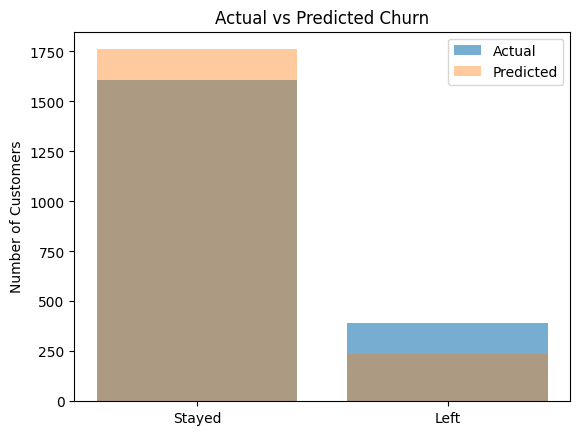

In [33]:
# === 1. Import libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# === 2. Load dataset ===
df = pd.read_csv("Churn_Modelling.csv")  # Make sure CSV is in the same folder
print("First 5 rows of dataset:")
print(df.head())

# === 3. Preprocessing ===
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode Gender (binary)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Features & target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 4. Build Neural Network (with improvement) ===
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))  # prevent overfitting
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # binary classification output

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=30, batch_size=16, verbose=1)

# === 5. Evaluate model ===
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()  # flatten to 1D for metrics

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:\n", cm)

# === Optional: Simple Bar Chart to visualize actual vs predicted churn ===
import matplotlib.pyplot as plt

plt.bar(['Stayed', 'Left'], [sum(y_test==0), sum(y_test==1)], alpha=0.6, label='Actual')
plt.bar(['Stayed', 'Left'], [sum(y_pred==0), sum(y_pred==1)], alpha=0.4, label='Predicted')
plt.ylabel("Number of Customers")
plt.title("Actual vs Predicted Churn")
plt.legend()
plt.show()
